# Initialization

In [ ]:
%pip install huggingface_hub
%pip install bgg-api
%pip install textstat

In [3]:
import json
#from huggingface_hub import InferenceClient


In [4]:
try:
    #DRIVE
    from google.colab import drive
    drive.mount('/content/drive',force_remount=True)
    BASE_FOLDER = 'drive/MyDrive/NLP_proj/'
except:
    #LOCAL
    BASE_FOLDER = '/home/prometheus/Proj/NLP_proj/'

In [5]:
GAME_NAMES = ["Ticket to Ride", "Dominion", "Catan", "Power Grid Recharged"]
MODELS = ['llama','qwen','gemma']

In [ ]:
with open(f'{BASE_FOLDER}/hf_api_key', 'r') as f:
    api_key = f.read()


client = InferenceClient(
    model="amd/gpt-oss-120b-chatbot",
    api_key=api_key,
)

def generate_message(sys_prompt, usr_prompt):
    return [
        {
                "role": "system",
                "content": sys_prompt,
            },
            {
                "role": "user",
                "content": usr_prompt,
            },
    ]

# Summarize

In [ ]:
response = {}
for model in models:
    with open(f'{BASE_FOLDER}summarize/{model}.out','r') as f:
        response[model] = json.load(f)

In [ ]:
for model in models:
    for game in file_names:
        for it in range(iterations):
            text = response[model][game][it]
            grade = textstat.flesch_kincaid_grade(text)
            print(f"Model: {model}, Game: {game}, Iteration: {it}, Grade: {grade}")

# Error Detection

In [ ]:
# READ FROM FILE
response = {}
for model in models:
    with open(f'drive/MyDrive/NLP_proj/{model}_error_detection.out','r') as f:
        response[model] = json.load(f)

In [ ]:
# EVALUATION
sys_prompt = """You are a rule‑checking assistant.
Read ANSWER and GROUND TRUTH, narrate whether the explanations refer to the same rule, and conclude with a single word **CORRECT** or **WRONG** on the final line.

### Examples
input:'''
ANSWER -> The Monopoly win condition states that the game ends when all other players have gone bankrupt,leaving a single player with all the assets. However, this rule can be problematic because it assumes that players will continue to take turns until bankruptcy occurs, which may never happen if a player repeatedly lands on “Free Parking” and collects cash without paying any fees. In such a scenario, the game could drag on indefinitely, making the win condition effectively unreachable. A more practical rule might impose a turn limit or a cash‑threshold to declare a winner when the game stalls.
GROUND TRUTH-> The problem is that the first player may reroll the dice any time.
'''

output:'''
The answer does not talk about rerolling the dice
WRONG
'''

---

input:'''
ANSWER ->  After examining the rulebook, I've identified a **gamebreaking** problem: In the first phase of the game rules states that when a player draws a card any other player can choose to draw another card. This could create a scenario where all player are willing to draw until the deck is empty.
GROUND TRUTH -> infinite card draw at the start of the game.
'''
output:'''
the answer and the ground truth adress the card draw in first phases of the game as the problem
CORRECT
'''

---

input:'''
ANSWER -> The rules appear consistent.
GROUND TRUTH -> The rulebook is consistent.
'''
'''
output:'''
both statements refer to the rule being consistent
CORRECT
'''
"""
ground_truth = {
    "ticket_to_ride": {
        "lvl0": "the rulebook is consistent",
        "lvl1": "In the rulebook it is not described how to claim a route",
        "lvl2": "In one section it is stated that during its turn a player may draw up to 2 train cards but on another line states that a player may draw up to 7 cards",
        "lvl3": "The \"a player cannot claim a route unless they have already claimed at least one other contiguous route earlier in the game\" creates a situation where a player may not clame its first route since it is not contiguous to other routes",
        "lvl4": "The rule that allows a player to reveal cards until they reveal a locomotive is unbalanced since it always allow a player to draw 2 locomotives per turn"
    },
    "dominion": {
        "lvl0": "the rulebook is consistent",
        "lvl1": "the buy phase section is missing",
        "lvl2": "the sentence \"After buying a card, a player may **continue to play additional Treasure cards** from their hand to increase their total  for that turn\" this is in direct contrast with a previous statement that does not allow a player to play treasures after the buy phase",
        "lvl3": "the sentence \"You cannot play cards that grant more action as the first action of the turn\" creates a situation where a player can't play card that grant extra action.",
        "lvl4": "the ability to play treasures also from the discard pile is unbalanced since allows player to have an ever increasing amount of gold to spend during their turn removing one of the balancing aspect of the game"
    },
    "7_wonders": {
        "lvl0": "the rulebook is consistent",
        "lvl1": "missing section explaining the resolution of military conflicts phase",
        "lvl2": "the sentence \"When buying a resource you may use Coins received from a neighbor earlier in the same turn to pay the 2‑Coin cost.\" contradicts a previous rules that states that a player cannot use coin recieved during the same turn to pay for a resource",
        "lvl3": "infinite resolve conflict loop",
        "lvl4": "the rule that allow a player to construct one stage of your Wonder for free is very unbalanced"
    },
    "catan": {
        "lvl0": "the rulebook is consistent",
        "lvl1": "missing subsection explaining building rules",
        "lvl2": "the sentence \"When you roll a 7, all hexes produce a resource except for the one with the robber.\" is directly in contrast with the rule stating that \"When you roll a 7, hexes do not produce any resources\"",
        "lvl3": "rules state that You can only trade a resource produced this turn by the hex with the robber, however since the hex with the robber does not produce resources this means that trading is not possible",
        "lvl4": "the rule stating that robber steals all resources from all players is very unbalanced since the player rolling a 7 is very likely to win the game"
    },
    "power_grid_recharged": {
        "lvl0": "the rulebook is consistent",
        "lvl1": "missing some steps in phase 5",
        "lvl2": "the sentence \"As explained in the section “The Power Plants”, each power plant may store only the number of resource tokens matching the number of symbols on the card and needs twice that number of tokens to produce electricity\" is contradicted later in the rules",
        "lvl3": "There is no way to reach phase 3 since the \"step 3\" card ir removed at the start of the game",
        "lvl4": "the rule granting a player who does not supply any city the same amount of Elektro as the highest‑earning player is unbalanced since it means that the player spending less resources is also gaining more Elektro than the others"
    }
}

evaluation_error_output = {m: {f'lvl{lvl}': {g: {
    'model_output': '',
    'ground_truth': '',
    'evaluation': '',
} }for g in file_names} for lvl in range(5)} for m in models}
for model in models:
    print(f"Model: {model}")
    for lvl in range(5):
        res = []
        # construct the answer pair
        answer_pair = []
        for game in file_names:
            for x in response[model][game][f'lvl{lvl}']:
                answer_pair.append((x, ground_truth[game][f'lvl{lvl}']))
        # check
        for answer, real in answer_pair:
            usr_prompt = f"ANSWER -> {answer}\nGROUND TRUTH -> {real}"
            out = client.chat_completion(messages=generate_message(sys_prompt, usr_prompt), temperature=0.7)
            out = out.choices[0].message.content
            # log the response
            evaluation_error_output[model][game][f'lvl{lvl}']['model_output'] = answer
            evaluation_error_output[model][game][f'lvl{lvl}']['ground_truth'] = real
            evaluation_error_output[model][game][f'lvl{lvl}']['evaluation'] = out

            if(VERBOSE):
                print(out)
            res.append(out.splitlines()[-1])
        print(f"lvl{lvl}: {res.count('CORRECT')}/{len(res)}")
with open('drive/MyDrive/NLP_proj/evaluation_error_output.json', 'w') as f:
    json.dump(evaluation_error_output, f, indent=4)

both statements refer to the rule being consistent
CORRECT
both statements refer to the rule being consistent
CORRECT
The answer and the ground truth both refer to the rulebook being consistent.
CORRECT
both statements refer to the rule being consistent
CORRECT
both statements refer to the rule being consistent
CORRECT
both statements refer to the rule being consistent
CORRECT
both statements refer to the rule being consistent
CORRECT
both statements refer to the rule being consistent
CORRECT
both statements refer to the rule being consistent
CORRECT
both statements refer to the rule being consistent
CORRECT
both statements refer to the rule being consistent
CORRECT
both statements refer to the rule being consistent
CORRECT
Both statements refer to the rule being consistent
CORRECT
Both statements refer to the rule being consistent
CORRECT
both statements refer to the rule being consistent
CORRECT
both statements refer to the rule being consistent
CORRECT
both statements refer to the r

# Estimation

In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("threnjen/board-games-database-from-boardgamegeek")

print("Path to dataset files:", path)

Path to dataset files: /home/prometheus/.cache/kagglehub/datasets/threnjen/board-games-database-from-boardgamegeek/versions/4


In [7]:
import pandas as pd
df = pd.read_csv(path+"/games.csv")

## READ FILE

In [9]:
import re

file_names = name_map.values()
parameters = ['complexity', 'mechanics', 'player', 'duration']
regex = {'mechanics': r"(?i)^.*\bmechanics\s*:\s*(\[.*\])\s*$",
         'complexity': r'(?i)^.*\bcomplexity.*:\s*([1-5]\.\d)',
         'player': r'(?i)^.*\bplayer.*:\s*(\d+).*',
         'duration': r'(?i)^.*\bduration.*:\s*(\d+)(?:-(\d+))?'

}
def retrieve_estimate():
    param_all = [p+'_all' for p in parameters]
    est = {g:{m:{p: [] for p in parameters + param_all} for m in MODELS}for g in file_names}
    for g in file_names:
        for m in MODELS:
            with open(f'{BASE_FOLDER}estimation/{m}_{g}.json','r') as f:
                raw = json.load(f)
            all_dic = {p:[] for p in parameters}
            for it in range(10):
                js = json.loads(raw['all'][str(it)])
                for p in parameters:
                    ## ALL
                    p2 = p if p != 'player' else 'optimal player count'
                    est[g][m][p+'_all'].append(js['answer'][p2])
                    ## SING
                    match = re.match(regex[p],
                                     raw[p][str(it)].rstrip().splitlines()[-1])
                    if not match:
                        print('the following line does not match:')
                        print(raw[p][str(it)].rstrip().splitlines()[-1])
                    else:
                        #TODO for ranges use the mean of the two matches
                        est[g][m][p].append(match.group(1))
    return est

#print(retrieve_estimate())

In [13]:
from matplotlib import pyplot as plt
import seaborn as sns
GAME_NAMES = ["Ticket to Ride", "Dominion", "Catan", "Power Grid"]
# tmp fix find a better solution
name_map = {"Ticket to Ride": 'ticket_to_ride', "Dominion":'dominion', "Catan":'catan', "Power Grid":'power_grid_recharged'}
gt = {name_map[g]: {
         'complexity': float(df.loc[df['Name'] == g, 'GameWeight'].values[0]),
         'duration': float(df.loc[df['Name'] == g, 'MfgPlaytime'].values[0]),
         'player': float(df.loc[df['Name'] == g, 'BestPlayers'].values[0])
         } for g in GAME_NAMES}

def print_param_est(est,g,p):
    plt.title(g)
    for m in MODELS:
        print(type(est[g][m][p+'_all'][0]))
        plt.axhline(y=gt[g][p], color = 'r')
        sns.swarmplot(x=[m]*len(est[g][m][p]), y=map(float,est[g][m][p]))
        sns.swarmplot(x=[m+'_all']*len(est[g][m][p+'_all']), y=map(float,est[g][m][p+'_all']))
    plt.show()
est = retrieve_estimate()
est

the following line does not match:
Based on my analysis, I recommend the optimal player count for Ticket to Ride to be 3-4 players. This player count offers a good balance between competition, social interaction, and gameplay complexity. With 3-4 players, the game is engaging, challenging, and fun, and players can enjoy a well-rounded experience.
the following line does not match:
Based on the analysis, I recommend the **optimal player count** to be **4 players**. This player count provides a good balance between competition, interaction, and play time. The game remains relatively balanced, and players have enough opportunities to achieve their goals without feeling overwhelmed.
the following line does not match:
While 2-player games can be enjoyable, they may become too straightforward, with less strategic depth. Games with 5 players may become too chaotic, with too much competition and blocking.
the following line does not match:
**Optimal player count:** 3-4 players
the following li

{'ticket_to_ride': {'llama': {'complexity': ['3.8',
    '4.1',
    '4.0',
    '3.8',
    '3.7',
    '4.2',
    '4.3',
    '4.3',
    '4.1',
    '4.0'],
   'mechanics': ['[Resource Management, Route Building, Hand Management, Ticket Collection, Scoring, End Game Bonuses, Variable Player Powers]',
    '[APAS, Resource Management, Area Control, Route Building, Ticket Collection/Completion, Variable Player Powers]',
    '[Action / Event, Variable Set-up, Tile Placement, Path Building, Variable Player Powers, Hand Management, Victory Points as a Resource, Area Majority / Influence, Pattern Building]',
    '[Drawing, Resource Queue, Area Movement, Resource Queue, Drawing, Hidden Victory Points, Victory Points as a Resource, Pattern Building, Track Movement]',
    '[Area Movement, Variable Player Powers, Variable Set-up, Worker Placement, Route Building, Pattern Building]',
    '[Automatic Resource Growth, Area Control, Set Collection, Tile Placement, Pattern Building, Variable Player Powers,

## COMPLEXITY

<class 'float'>
<class 'float'>
<class 'float'>


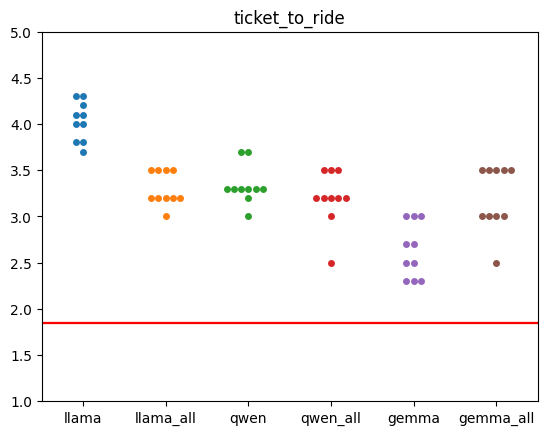

<class 'float'>
<class 'float'>
<class 'float'>


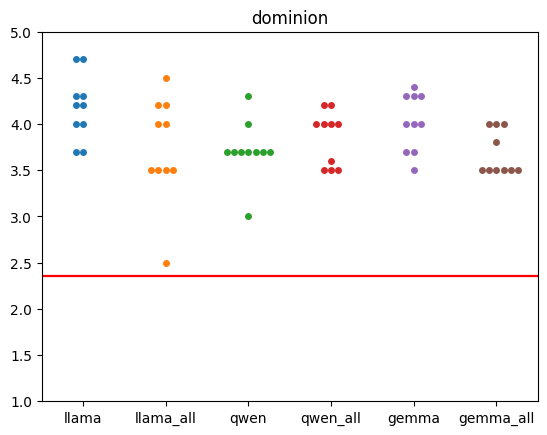

<class 'float'>
<class 'float'>
<class 'float'>


/home/prometheus/anaconda3/envs/llama-env/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 10.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


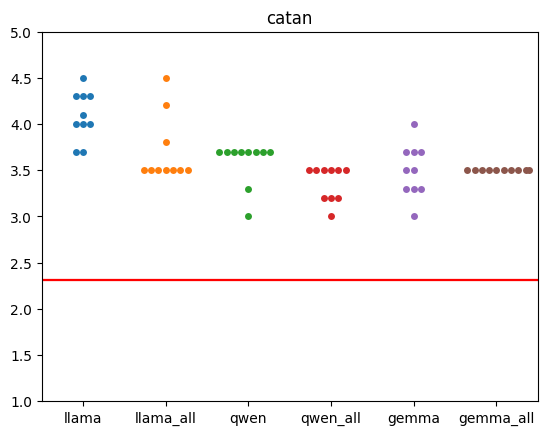

<class 'float'>
<class 'float'>
<class 'float'>


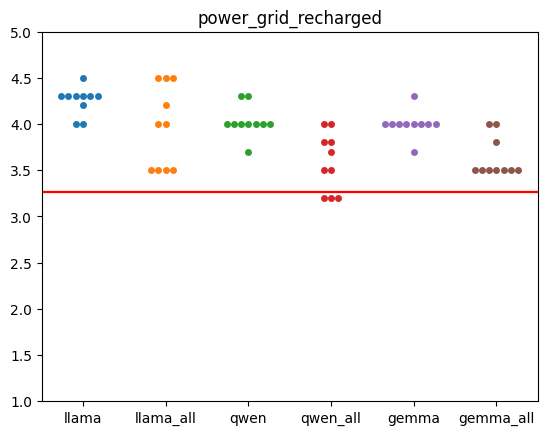

In [14]:
for g in file_names:
    plt.ylim(1,5)
    print_param_est(est,g,'complexity')

## OPTIMAL PLAYER COUNT

<class 'int'>
<class 'int'>
<class 'int'>


/home/prometheus/anaconda3/envs/llama-env/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 10.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


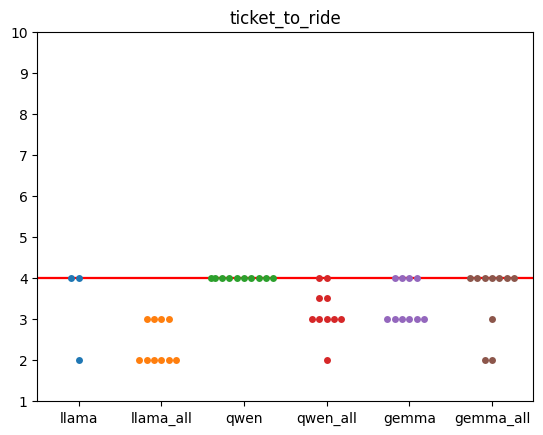

<class 'int'>
<class 'int'>
<class 'int'>


/home/prometheus/anaconda3/envs/llama-env/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 10.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


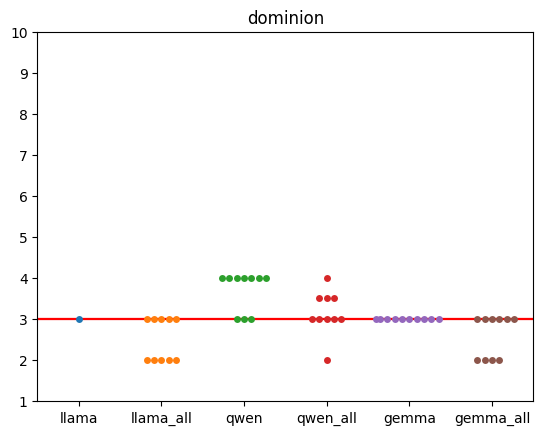

<class 'int'>
<class 'int'>
<class 'int'>


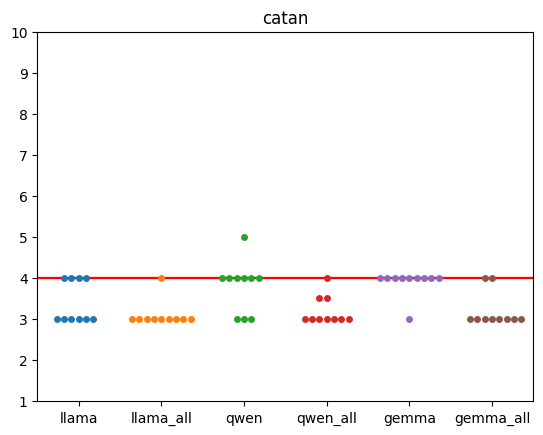

<class 'int'>
<class 'float'>
<class 'int'>


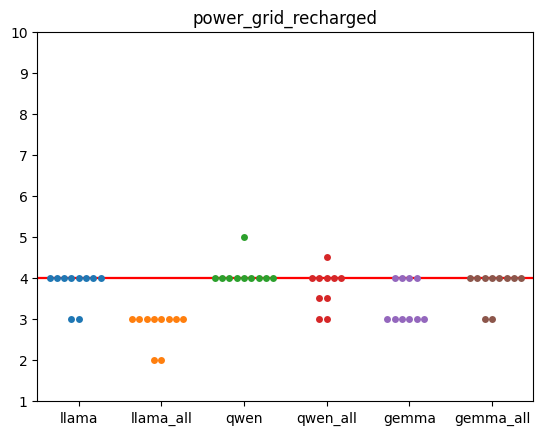

In [15]:
for g in file_names:
    plt.ylim(1,10)
    print_param_est(est,g,'player')

## DURATION

<class 'int'>
<class 'int'>
<class 'int'>


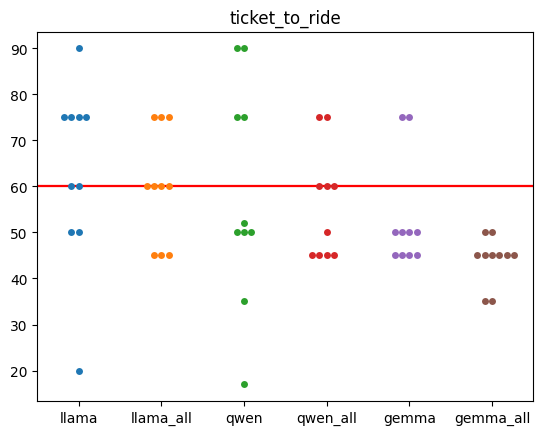

<class 'int'>
<class 'int'>
<class 'int'>


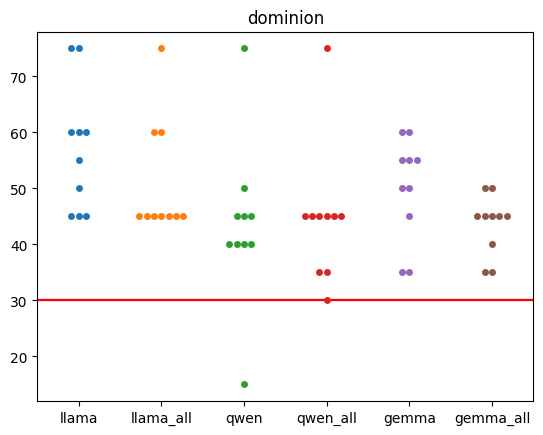

<class 'int'>
<class 'int'>
<class 'int'>


/home/prometheus/anaconda3/envs/llama-env/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 10.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


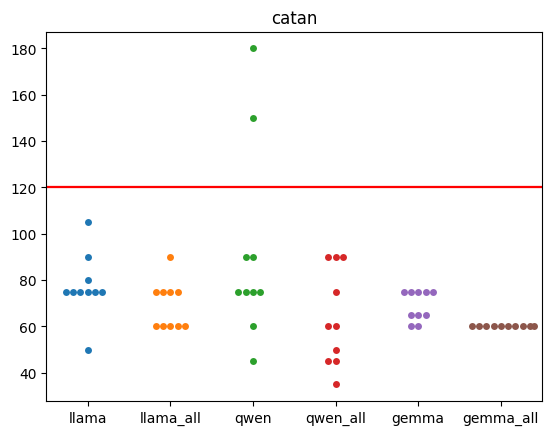

<class 'int'>
<class 'int'>
<class 'int'>


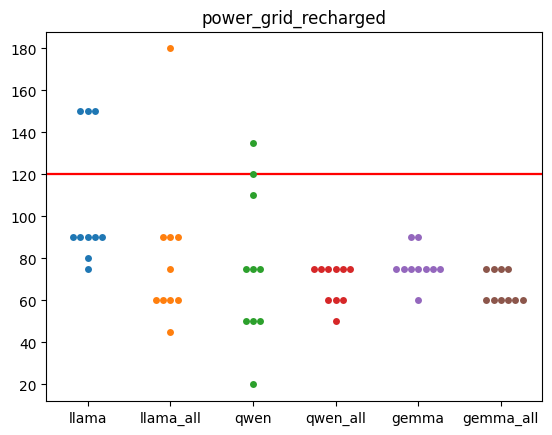

In [98]:
for g in file_names:
    print_param_est(est,g,'duration')

In [99]:
# EVALUATION
from boardgamegeek import BGGClient
bgg = BGGClient()
bgg_gt = []

for gn in GAME_NAMES:
    game = bgg.game(gn)
    bgg_gt.append(gn.lower().replace(" ", "_"), game.mechanics, game.complexity, game.minplayers, game.maxplayers, game.playingtime)
print(bgg_gt)



ModuleNotFoundError: No module named 'boardgamegeek'